# Customer Lifetime Value Estimation with BG/NBD and Gamma-Gamma Models

This notebook estimates customer lifetime value from retail transaction data using a two-stage probabilistic modelling framework. The BG/NBD model is used to estimate future purchase frequency, while the Gamma-Gamma model is used to estimate the expected monetary value of future transactions.

The workflow follows four main stages: data preparation, purchase-frequency modelling, monetary-value modelling, and customer segmentation. The modelling specification is kept consistent with the project report so that the numerical outputs remain comparable with the documented results.


## 1. Data Loading and Initial Inspection

The raw transaction dataset is loaded and inspected before modelling. This step checks the basic structure, available columns, and data types.


In [1]:
import pandas as pd
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_probability_alive_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import silhouette_score


In [2]:
retail_df = pd.read_csv("data/raw/data.csv")
retail_df.head()


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [3]:
retail_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  str    
 2   Customer_Name      1000000 non-null  str    
 3   Product            1000000 non-null  str    
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  str    
 7   City               1000000 non-null  str    
 8   Store_Type         1000000 non-null  str    
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  str    
 11  Season             1000000 non-null  str    
 12  Promotion          666057 non-null   str    
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 92.5 MB


## 2. Data Preparation

The data is cleaned by converting the transaction date to datetime format, removing invalid transactions, dropping missing customer identifiers, and eliminating duplicate records. The final six months of the dataset are reserved as the holdout period for later comparison with model predictions.


In [4]:
retail_df['Date'] = pd.to_datetime(retail_df['Date'])

retail_clean = retail_df[
    (retail_df['Total_Cost'] > 0) &
    (retail_df['Total_Items'] > 0)
].copy()

retail_clean.dropna(subset=['Customer_Name'], inplace=True)

# Normalize customer name to reduce accidental duplicates caused by whitespace
retail_clean['Customer_Name'] = retail_clean['Customer_Name'].astype(str).str.strip()

retail_clean.drop_duplicates(inplace=True)

# Sort data before creating RFMT summaries
retail_clean = retail_clean.sort_values(['Customer_Name', 'Date']).reset_index(drop=True)

print(retail_clean.shape)


(1000000, 13)


### Exploratory Data Analysis

#### Dataset Overview

In [5]:
basic_data_overview = pd.DataFrame({
    'Metric': [
        'Number of rows',
        'Number of columns',
        'Number of unique customers',
        'Start date',
        'End date',
        'Number of unique products',
        'Number of duplicate rows'
    ],
    'Value': [
        len(retail_clean),
        retail_clean.shape[1],
        retail_clean['Customer_Name'].nunique(),
        retail_clean['Date'].min(),
        retail_clean['Date'].max(),
        retail_clean['Product'].nunique() if 'Product' in retail_clean.columns else 'N/A',
        retail_clean.duplicated().sum()
    ]
})

basic_data_overview

,Metric,Value
0,Number of rows,1000000
1,Number of columns,13
2,Number of unique customers,329738
3,Start date,2020-01-01 00:03:54
4,End date,2024-05-18 19:31:03
5,Number of unique products,571947
6,Number of duplicate rows,0


#### Missing Values and Invalid Transaction Checks

In [6]:
key_cols = ['Customer_Name', 'Date', 'Total_Cost', 'Total_Items']

available_key_cols = [col for col in key_cols if col in retail_clean.columns]

missing_check = (
    retail_clean[available_key_cols]
    .isna()
    .sum()
    .reset_index()
)

missing_check.columns = ['Column', 'Missing values']

invalid_transaction_check = pd.DataFrame({
    'Check': [
        'Transactions with Total_Cost <= 0',
        'Transactions with Total_Items <= 0'
    ],
    'Count': [
        (retail_clean['Total_Cost'] <= 0).sum(),
        (retail_clean['Total_Items'] <= 0).sum()
    ]
})

display(missing_check)
display(invalid_transaction_check)

,Column,Missing values
0,Customer_Name,0
1,Date,0
2,Total_Cost,0
3,Total_Items,0


,Check,Count
0,Transactions with Total_Cost <= 0,0
1,Transactions with Total_Items <= 0,0


In [7]:
transaction_value_summary = retail_clean['Total_Cost'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).to_frame(name='Total_Cost')

transaction_value_summary

,Total_Cost
count,1000000.000000
mean,52.455220
std,27.416989
min,5.000000
1%,5.950000
5%,9.720000
25%,28.710000
50%,52.420000
75%,76.190000
95%,95.230000


#### Transaction Value Distribution

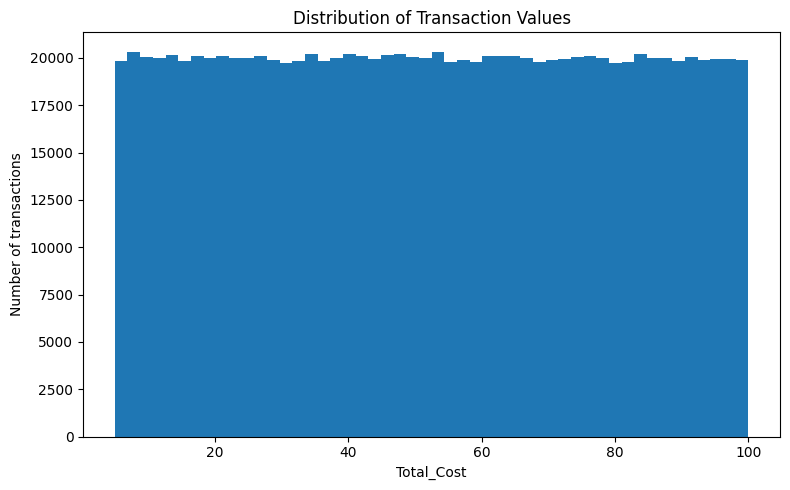

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    retail_clean['Total_Cost'],
    bins=50
)

plt.xlabel('Total_Cost')
plt.ylabel('Number of transactions')
plt.title('Distribution of Transaction Values')
plt.tight_layout()
plt.show()

#### Transaction Trend Over Time

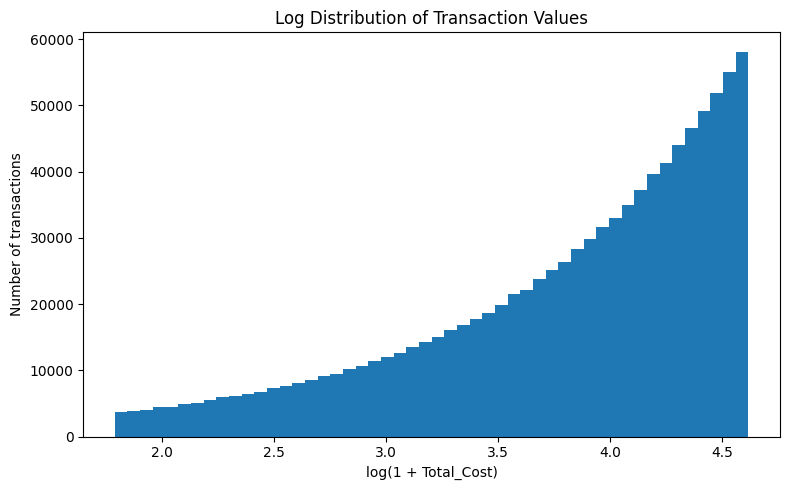

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(retail_clean['Total_Cost']),
    bins=50
)

plt.xlabel('log(1 + Total_Cost)')
plt.ylabel('Number of transactions')
plt.title('Log Distribution of Transaction Values')
plt.tight_layout()
plt.show()

In [10]:
monthly_transactions = (
    retail_clean
    .set_index('Date')
    .resample('ME')
    .size()
    .reset_index(name='transaction_count')
)

monthly_transactions.head()

,Date,transaction_count
0,2020-01-31,19486
1,2020-02-29,18198
2,2020-03-31,19328
3,2020-04-30,18855
4,2020-05-31,19060


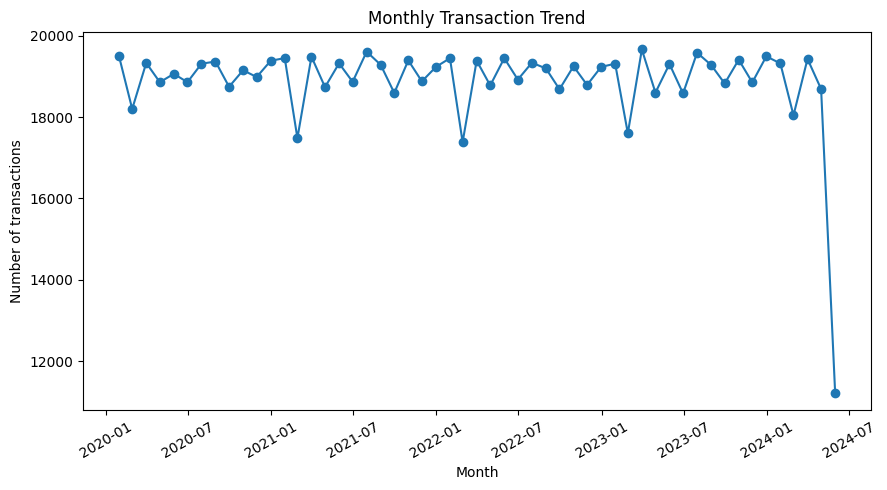

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_transactions['Date'],
    monthly_transactions['transaction_count'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Number of transactions')
plt.title('Monthly Transaction Trend')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
calibration_end_date = retail_clean['Date'].max() - pd.DateOffset(months=6)

calibration_data = retail_clean[retail_clean['Date'] <= calibration_end_date].copy()
holdout_data = retail_clean[retail_clean['Date'] > calibration_end_date].copy()

holdout_days = (
    holdout_data['Date'].max().floor('D') -
    holdout_data['Date'].min().floor('D')
).days + 1

print("Calibration end date:", calibration_end_date)
print("Holdout start date:", holdout_data['Date'].min())
print("Holdout end date:", holdout_data['Date'].max())
print("Holdout length in days:", holdout_days)

Calibration end date: 2023-11-18 19:31:03
Holdout start date: 2023-11-18 19:35:23
Holdout end date: 2024-05-18 19:31:03
Holdout length in days: 183


## 3. RFMT Summary Construction

The transaction data is transformed into an RFMT summary table required by the BG/NBD and Gamma-Gamma models.

The variables are defined as follows:

- `frequency`: number of repeat purchase periods during the calibration period. Because the model uses `freq='D'`, this is interpreted as repeat purchase days/periods rather than raw transaction rows.
- `recency`: time between the first and most recent purchase.
- `T`: customer age at the end of the calibration period.
- `monetary_value`: average transaction value for repeat customers.

Only customers with at least one repeat purchase are retained for the modelling dataset.


In [13]:
current_date = calibration_data['Date'].max()

rfm_summary = summary_data_from_transaction_data(
    calibration_data,
    customer_id_col='Customer_Name',
    datetime_col='Date',
    monetary_value_col='Total_Cost',
    observation_period_end=current_date,
    freq='D'
)

# BG/NBD + Gamma-Gamma model is fitted on repeat customers only
rfm_summary = rfm_summary[
    (rfm_summary['frequency'] > 0) &
    (rfm_summary['monetary_value'] > 0)
].copy()

rfm_summary.head()

,frequency,recency,T,monetary_value
Customer_Name,,,,
Aaron Acevedo,3.0,1205.0,1272.0,63.263333
Aaron Acosta,2.0,621.0,1275.0,73.250000
Aaron Adams,10.0,1097.0,1196.0,59.665000
Aaron Adkins,2.0,874.0,1085.0,44.110000
Aaron Aguilar,3.0,1051.0,1341.0,49.130000


### Additional Data Check: Impact of Filtering Repeat Customers

The Gamma-Gamma model requires customers with repeat purchases and positive monetary value. Therefore, the main modeling dataset keeps customers with `frequency > 0`.

This check measures how many customers are excluded because they are one-time buyers.

The purpose is to acknowledge that the final CLV model focuses on repeat customers, while one-time buyers would require a separate treatment or model in a real business setting.

In [14]:
# Recreate RFMT summary before filtering frequency > 0
rfm_all_customers = summary_data_from_transaction_data(
    calibration_data,
    customer_id_col='Customer_Name',
    datetime_col='Date',
    monetary_value_col='Total_Cost',
    observation_period_end=calibration_data['Date'].max(),
    freq='D'
)

total_customers_before_filter = len(rfm_all_customers)
repeat_customers = (rfm_all_customers['frequency'] > 0).sum()
one_time_customers = (rfm_all_customers['frequency'] == 0).sum()

repeat_customer_filter_audit = pd.DataFrame({
    'Metric': [
        'Total customers before frequency filter',
        'Repeat customers kept (frequency > 0)',
        'One-time buyers excluded (frequency = 0)',
        'Share of customers kept',
        'Share of customers excluded'
    ],
    'Value': [
        total_customers_before_filter,
        repeat_customers,
        one_time_customers,
        repeat_customers / total_customers_before_filter,
        one_time_customers / total_customers_before_filter
    ]
})

repeat_customer_filter_audit

,Metric,Value
0,Total customers before frequency filter,308666.000000
1,Repeat customers kept (frequency > 0),139004.000000
2,One-time buyers excluded (frequency = 0),169662.000000
3,Share of customers kept,0.450338
4,Share of customers excluded,0.549662


In [15]:
rfmt_summary_stats = rfm_summary[
    ['frequency', 'recency', 'T', 'monetary_value']
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

rfmt_summary_stats

,frequency,recency,T,monetary_value
count,139004.000000,139004.000000,139004.000000,139004.000000
mean,4.124773,747.712087,1083.399600,52.541773
std,7.860614,395.348696,298.821144,20.882141
min,1.000000,1.000000,4.000000,5.000000
1%,1.000000,19.000000,217.000000,7.310150
5%,1.000000,88.000000,462.150000,15.525250
25%,1.000000,418.000000,917.000000,39.360000
50%,2.000000,776.000000,1173.000000,52.690000
75%,4.000000,1090.000000,1324.000000,65.710000
95%,14.000000,1329.000000,1403.000000,89.274250


In [16]:
def add_holdout_actuals(rfm_df, holdout_df):
    """
    Add holdout actuals aligned with Lifetimes daily frequency.

    actual_6m:
        Number of unique customer-day purchase periods in holdout.
        This aligns with freq='D' in Lifetimes.

    actual_transactions_6m:
        Raw number of transaction rows in holdout.
        Used only for monetary-value diagnostics.

    actual_value_6m:
        Total transaction value in holdout.
    """
    holdout_tmp = holdout_df.copy()
    holdout_tmp['Purchase_Day'] = holdout_tmp['Date'].dt.floor('D')

    actual_purchase_days = (
        holdout_tmp
        .drop_duplicates(['Customer_Name', 'Purchase_Day'])
        .groupby('Customer_Name')
        .size()
    )

    actual_transactions = holdout_tmp.groupby('Customer_Name').size()
    actual_value = holdout_tmp.groupby('Customer_Name')['Total_Cost'].sum()
    actual_avg_transaction_value = holdout_tmp.groupby('Customer_Name')['Total_Cost'].mean()

    rfm_df['actual_6m'] = actual_purchase_days.reindex(rfm_df.index).fillna(0)
    rfm_df['actual_transactions_6m'] = actual_transactions.reindex(rfm_df.index).fillna(0)
    rfm_df['actual_value_6m'] = actual_value.reindex(rfm_df.index).fillna(0)
    rfm_df['actual_avg_transaction_value_6m'] = actual_avg_transaction_value.reindex(rfm_df.index)
    rfm_df['actual_active_6m'] = (rfm_df['actual_6m'] > 0).astype(int)

    return rfm_df


In [17]:
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['pred_1m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['pred_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    holdout_days,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['pred_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['p_alive'] = bgf.conditional_probability_alive(
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary = add_holdout_actuals(rfm_summary, holdout_data)

rfm_summary[
    ['pred_6m', 'actual_6m', 'actual_transactions_6m', 'actual_active_6m', 'actual_value_6m']
].head()


,pred_6m,actual_6m,actual_transactions_6m,actual_active_6m,actual_value_6m
Customer_Name,,,,,
Aaron Acevedo,0.496225,0.0,0.0,0,0.00
Aaron Acosta,0.318655,0.0,0.0,0,0.00
Aaron Adams,1.321378,1.0,1.0,1,80.04
Aaron Adkins,0.420329,0.0,0.0,0,0.00
Aaron Aguilar,0.464835,1.0,1.0,1,56.16


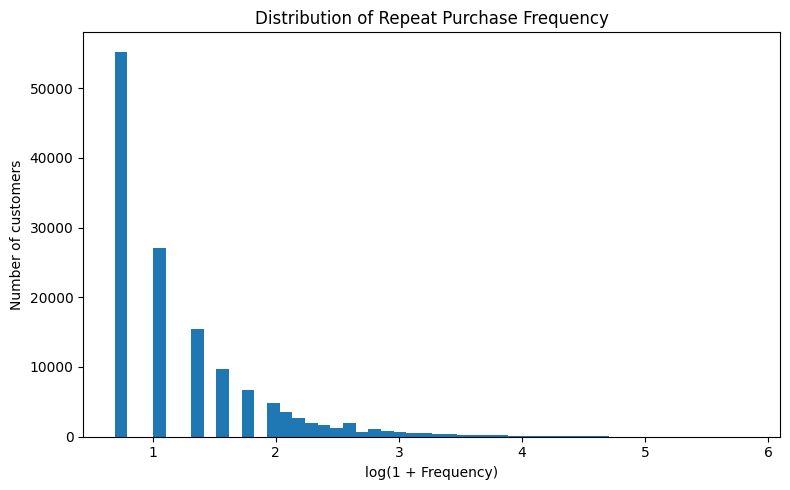

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(rfm_summary['frequency']),
    bins=50
)

plt.xlabel('log(1 + Frequency)')
plt.ylabel('Number of customers')
plt.title('Distribution of Repeat Purchase Frequency')
plt.tight_layout()
plt.show()

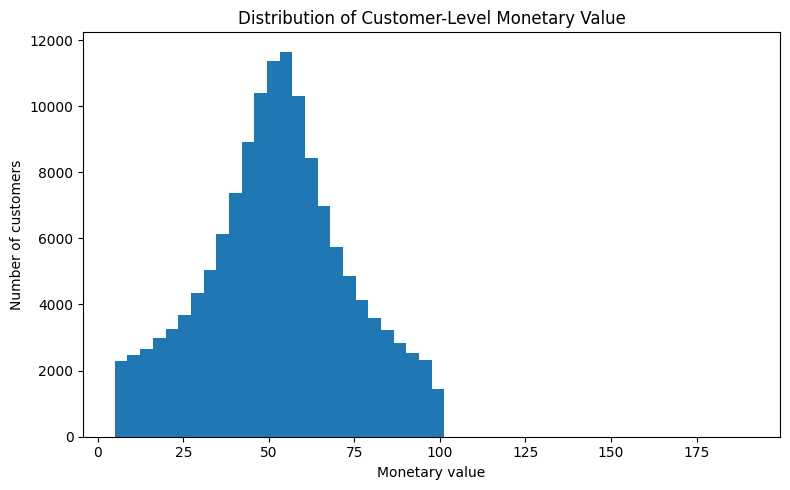

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm_summary['monetary_value'],
    bins=50
)

plt.xlabel('Monetary value')
plt.ylabel('Number of customers')
plt.title('Distribution of Customer-Level Monetary Value')
plt.tight_layout()
plt.show()

## 4. BG/NBD Model for Purchase Frequency

The BG/NBD model estimates the expected number of future purchases and the probability that a customer is still active. Predictions are generated for one-month, six-month, and twelve-month horizons.


In [20]:
summary_bgnbd = pd.DataFrame({
    'Coef': bgf.params_,
    'Se (coef)': bgf.standard_errors_,
    'Lower 95% bound': bgf.confidence_intervals_['lower 95% bound'],
    'Upper 95% bound': bgf.confidence_intervals_['upper 95% bound']
})

summary_bgnbd


,Coef,Se (coef),Lower 95% bound,Upper 95% bound
r,1.668658,0.008328,1.652335,1.684980
alpha,395.606303,2.213100,391.268627,399.943979
a,0.051622,0.001538,0.048608,0.054635
b,0.255405,0.008034,0.239658,0.271152


## 5. Purchase-Frequency Validation

The predicted six-month purchase frequency is compared with observed purchasing activity in the holdout period.

Because the model is estimated with `freq='D'`, the actual holdout target is defined as the number of unique customer-day purchase periods, not raw transaction rows.


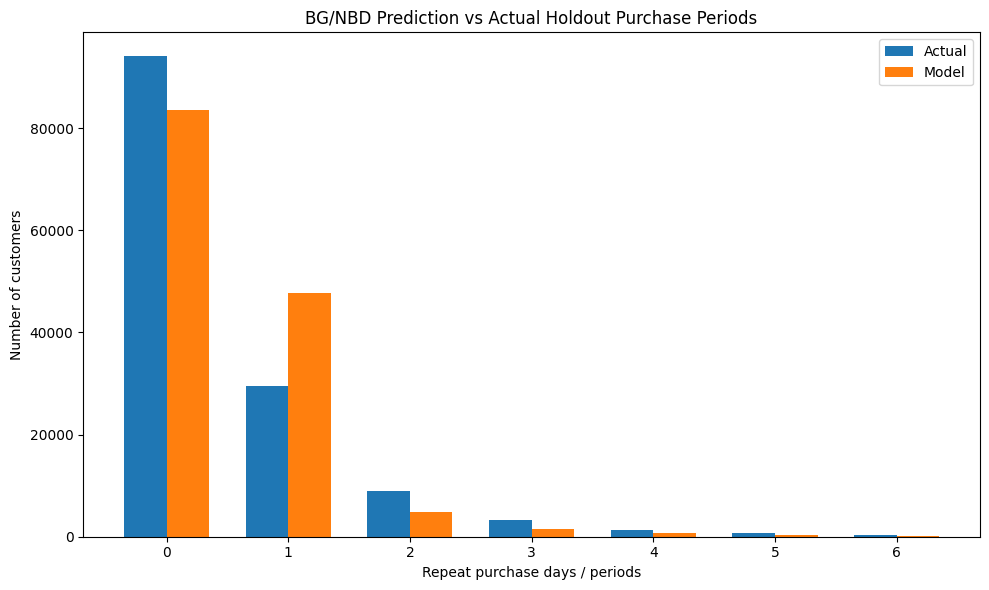

In [21]:
max_trans = 6

actual_counts = rfm_summary['actual_6m'].value_counts().sort_index()
pred_counts = rfm_summary['pred_6m'].round().value_counts().sort_index()

x = np.arange(max_trans + 1)
actual_plot = [actual_counts.get(i, 0) for i in x]
pred_plot = [pred_counts.get(i, 0) for i in x]

plt.figure(figsize=(10, 6))
width = 0.35

plt.bar(x - width / 2, actual_plot, width, label='Actual')
plt.bar(x + width / 2, pred_plot, width, label='Model')

plt.xlabel('Repeat purchase days / periods')
plt.ylabel('Number of customers')
plt.title('BG/NBD Prediction vs Actual Holdout Purchase Periods')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


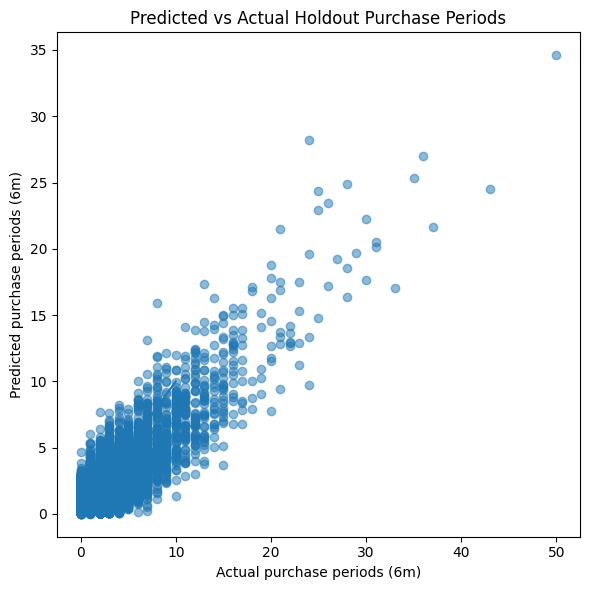

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(rfm_summary['actual_6m'], rfm_summary['pred_6m'], alpha=0.5)

plt.xlabel('Actual purchase periods (6m)')
plt.ylabel('Predicted purchase periods (6m)')
plt.title('Predicted vs Actual Holdout Purchase Periods')
plt.plot([0, 10], [0, 10])
plt.tight_layout()
plt.show()


### Additional Validation 1: BG/NBD Holdout Prediction Metrics

This step evaluates how well the BG/NBD model predicts the number of repeat purchase periods in the 6-month holdout period.

Because the model is estimated with `freq='D'`, the actual holdout target is defined as the number of unique customer-day purchase periods, not the raw number of transaction rows.

We compare predicted purchase periods with actual holdout purchase periods using four metrics:

- **MAE**: average absolute prediction error.
- **RMSE**: prediction error with stronger penalty for large errors.
- **Bias**: average difference between predicted and actual purchase periods.
- **Correlation**: how strongly predicted purchase periods move together with actual purchase periods.

This validation helps assess whether the BG/NBD purchase-frequency prediction is reliable enough to support CLV estimation.


In [23]:
# Predicted number of purchase periods in 6 months already exists as pred_6m
# Actual holdout activity has already been added by add_holdout_actuals()
y_true = rfm_summary['actual_6m']
y_pred = rfm_summary['pred_6m']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = (y_pred - y_true).mean()
corr = y_true.corr(y_pred)

purchase_validation_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'Bias mean(pred - actual)', 'Correlation'],
    'Value': [mae, rmse, bias, corr]
})

purchase_validation_metrics


,Metric,Value
0,MAE,0.565926
1,RMSE,0.813347
2,Bias mean(pred - actual),0.045787
3,Correlation,0.771315


### Defining Actual Customer Activity in Holdout

This step creates a binary indicator called `actual_active_6m`.

A customer is defined as active in the holdout period if they made at least one purchase-day/period during the 6-month holdout window.

This variable is used to check whether customers with higher predicted `p_alive` are also more likely to purchase again in the holdout period.


In [24]:
# A customer is considered active in the holdout period
# if they have at least 1 purchase-day/period in the 6-month holdout period.
rfm_summary['actual_active_6m'] = (rfm_summary['actual_6m'] > 0).astype(int)

rfm_summary[['p_alive', 'actual_6m', 'actual_active_6m']].head()


,p_alive,actual_6m,actual_active_6m
Customer_Name,,,
Aaron Acevedo,0.973030,0.0,0
Aaron Acosta,0.797217,0.0,0
Aaron Adams,0.988338,1.0,1
Aaron Adkins,0.932594,0.0,0
Aaron Aguilar,0.949026,1.0,1


### Grouping Customers by Predicted p_alive

This step ranks customers by their predicted probability of being alive and divides them into 10 deciles.

- Decile 1 contains customers with the lowest predicted `p_alive`.
- Decile 10 contains customers with the highest predicted `p_alive`.

The purpose is to evaluate whether higher predicted `p_alive` groups also show stronger actual activity in the holdout period.

In [25]:
# Rank first to avoid problems when many customers have identical p_alive values
rfm_summary['p_alive_rank'] = rfm_summary['p_alive'].rank(method='first')

# Divide customers into 10 groups based on predicted p_alive
# Decile 1 = lowest p_alive
# Decile 10 = highest p_alive
rfm_summary['p_alive_decile'] = pd.qcut(
    rfm_summary['p_alive_rank'],
    q=10,
    labels=False
) + 1

rfm_summary[['p_alive', 'p_alive_decile', 'actual_active_6m']].head()

,p_alive,p_alive_decile,actual_active_6m
Customer_Name,,,
Aaron Acevedo,0.973030,8,0
Aaron Acosta,0.797217,5,0
Aaron Adams,0.988338,10,1
Aaron Adkins,0.932594,6,0
Aaron Aguilar,0.949026,7,1


### Comparing Predicted p_alive with Actual Holdout Activity

This step compares predicted `p_alive` with actual customer behavior in the holdout period.

For each `p_alive` decile, we calculate:

- the number of customers,
- the average predicted `p_alive`,
- the actual active rate in the 6-month holdout period,
- the average number of actual holdout transactions.

If higher `p_alive` deciles have higher actual active rates or higher actual transactions, this supports the use of `p_alive` as an indicator of future customer activity.

In [26]:
p_alive_validation = (
    rfm_summary
    .groupby('p_alive_decile')
    .agg(
        customers=('actual_active_6m', 'size'),
        min_p_alive=('p_alive', 'min'),
        max_p_alive=('p_alive', 'max'),
        avg_predicted_p_alive=('p_alive', 'mean'),
        actual_active_rate=('actual_active_6m', 'mean'),
        avg_actual_purchase_periods=('actual_6m', 'mean')
    )
    .reset_index()
)

p_alive_validation

,p_alive_decile,customers,min_p_alive,max_p_alive,avg_predicted_p_alive,actual_active_rate,avg_actual_purchase_periods
0,1,13901,0.047552,0.412797,0.274367,0.171355,0.199266
1,2,13900,0.412834,0.602374,0.514566,0.180216,0.212734
2,3,13900,0.602401,0.720118,0.666255,0.192158,0.226547
3,4,13901,0.720131,0.794838,0.760146,0.187037,0.224013
4,5,13900,0.794840,0.873661,0.826097,0.225036,0.282734
5,6,13900,0.873680,0.934704,0.910051,0.306547,0.397122
6,7,13901,0.934704,0.957833,0.947747,0.316740,0.423135
7,8,13900,0.957839,0.975795,0.967446,0.384029,0.550072
8,9,13900,0.975797,0.987756,0.982071,0.501871,0.793741
9,10,13901,0.987756,0.999817,0.993088,0.768937,2.240558


### Visualization: p_alive Validation by Decile

This chart visualizes the relationship between predicted `p_alive` and actual active rate.

The chart helps show whether customers with higher predicted activity probability also have higher observed activity in the holdout period.

The two lines should not be interpreted as perfectly identical measures, because `p_alive` represents the probability that a customer is still active, while actual active rate is based on whether the customer made at least one transaction in the 6-month holdout period.

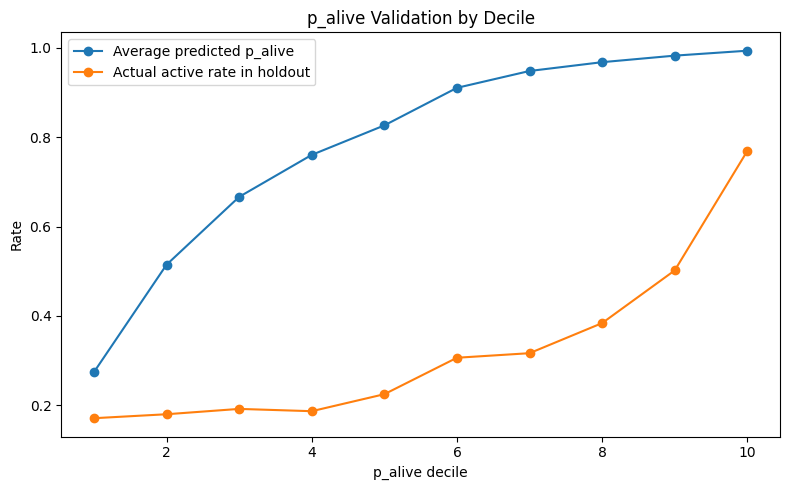

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    p_alive_validation['p_alive_decile'],
    p_alive_validation['avg_predicted_p_alive'],
    marker='o',
    label='Average predicted p_alive'
)

plt.plot(
    p_alive_validation['p_alive_decile'],
    p_alive_validation['actual_active_rate'],
    marker='o',
    label='Actual active rate in holdout'
)

plt.xlabel('p_alive decile')
plt.ylabel('Rate')
plt.title('p_alive Validation by Decile')
plt.legend()
plt.tight_layout()
plt.show()

### Low-vs-High p_alive Comparison

This step compares the lowest and highest `p_alive` deciles directly.

The comparison provides a simple interpretation of model usefulness:

- customers in the lowest `p_alive` group should have weaker actual activity,
- customers in the highest `p_alive` group should have stronger actual activity.

This result is useful for explaining why `p_alive` is meaningful for customer segmentation.

In [28]:
lowest_decile = p_alive_validation['p_alive_decile'].min()
highest_decile = p_alive_validation['p_alive_decile'].max()

comparison_low_high = p_alive_validation[
    p_alive_validation['p_alive_decile'].isin([lowest_decile, highest_decile])
]

comparison_low_high

,p_alive_decile,customers,min_p_alive,max_p_alive,avg_predicted_p_alive,actual_active_rate,avg_actual_purchase_periods
0,1,13901,0.047552,0.412797,0.274367,0.171355,0.199266
9,10,13901,0.987756,0.999817,0.993088,0.768937,2.240558


### Interpretation of p_alive Validation

The validation result supports the usefulness of `p_alive`.

Customers in higher `p_alive` deciles should have a higher actual active rate in the holdout period than customers in lower `p_alive` deciles. This table is therefore used to check whether the BG/NBD model ranks customers' activity status in a meaningful way.

The exact values should be read from the validation table above after running the notebook. Avoid hard-coding these numbers in the notebook text because they may change when the data cleaning or holdout definition is updated.

However, `p_alive` should not be interpreted as the exact probability of making a purchase within six months. It represents the model-estimated probability that the customer is still active, while actual holdout activity is measured by whether the customer made at least one observed purchase period.


### Additional Robustness Check: BG/NBD vs Naive Baseline

This check compares the BG/NBD purchase prediction with a simple naive baseline.

The naive baseline assumes that each customer's future purchase count is proportional to their historical repeat purchase rate:

`naive_predicted_purchases = historical_purchase_rate × holdout_days`

The purpose is to check whether BG/NBD provides better predictive performance than a simple historical-rate rule.

This helps justify the use of BG/NBD instead of relying only on a simple average-based prediction.

In [29]:
# Naive baseline:
# historical repeat purchase-period rate = frequency / T
# future purchase periods = historical rate × holdout_days
rfm_summary['naive_pred_6m'] = (
    rfm_summary['frequency'] / rfm_summary['T'].replace(0, np.nan)
) * holdout_days

rfm_summary['naive_pred_6m'] = rfm_summary['naive_pred_6m'].fillna(0)

y_true = rfm_summary['actual_6m']
y_pred_bgnbd = rfm_summary['pred_6m']
y_pred_naive = rfm_summary['naive_pred_6m']

baseline_comparison = pd.DataFrame({
    'Model': ['BG/NBD', 'Naive historical-rate baseline'],
    'MAE': [
        mean_absolute_error(y_true, y_pred_bgnbd),
        mean_absolute_error(y_true, y_pred_naive)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_true, y_pred_bgnbd)),
        np.sqrt(mean_squared_error(y_true, y_pred_naive))
    ],
    'Bias mean(pred - actual)': [
        (y_pred_bgnbd - y_true).mean(),
        (y_pred_naive - y_true).mean()
    ],
    'Correlation with actual': [
        y_true.corr(y_pred_bgnbd),
        y_true.corr(y_pred_naive)
    ]
})

baseline_comparison

,Model,MAE,RMSE,Bias mean(pred - actual),Correlation with actual
0,BG/NBD,0.565926,0.813347,0.045787,0.771315
1,Naive historical-rate baseline,0.576883,0.832915,0.105053,0.756488


## 6. Customer Activity Probability

The probability-alive output indicates how likely each customer is to remain active according to the BG/NBD model. The distribution and retention-probability matrix help interpret how purchase frequency and recency affect customer activity.


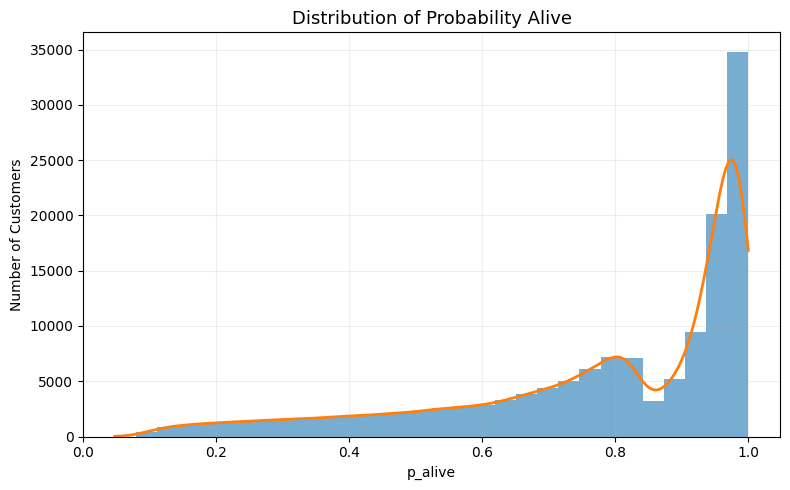

In [30]:
plt.figure(figsize=(8, 5))

counts, bins, _ = plt.hist(
    rfm_summary['p_alive'],
    bins=30,
    alpha=0.6
)

kde = gaussian_kde(rfm_summary['p_alive'])
x_vals = np.linspace(rfm_summary['p_alive'].min(), rfm_summary['p_alive'].max(), 200)
y_vals = kde(x_vals)
y_vals_scaled = y_vals * len(rfm_summary['p_alive']) * (bins[1] - bins[0])

plt.plot(x_vals, y_vals_scaled, linewidth=2)
plt.title('Distribution of Probability Alive', fontsize=13)
plt.xlabel('p_alive')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


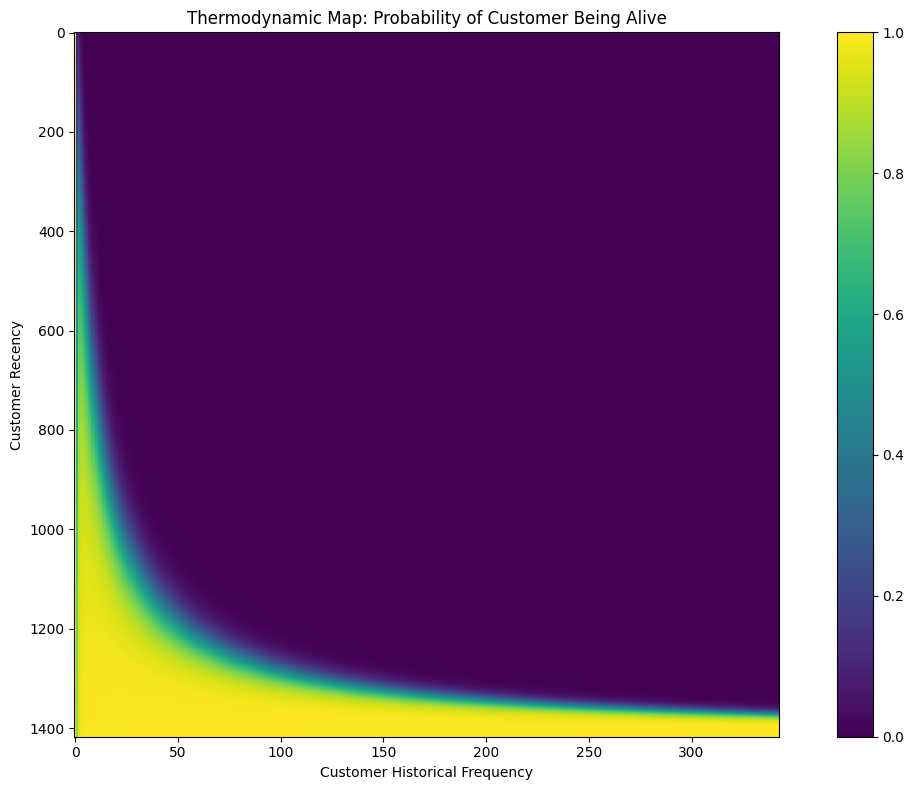

In [31]:
plt.figure(figsize=(12, 8))
plot_probability_alive_matrix(bgf)

plt.title('Thermodynamic Map: Probability of Customer Being Alive')
plt.xlabel('Customer Historical Frequency')
plt.ylabel('Customer Recency')
plt.tight_layout()
plt.show()


## 7. Gamma-Gamma Model for Monetary Value

The Gamma-Gamma model is used to estimate each customer's expected average transaction value. This estimate is combined with BG/NBD purchase-frequency predictions to calculate revenue-based CLV.

Because the dataset does not include profit margin, campaign cost, or cost-to-serve, the monetary value in this project should be interpreted as transaction value rather than profit.

The Gamma-Gamma model is evaluated in two ways:

1. checking the independence assumption between purchase frequency and monetary value;
2. diagnosing the model's ability to predict average transaction value in the holdout period.

The second check is treated as a limitation diagnostic, not as the main evidence of model success.

In [32]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    rfm_summary['frequency'],
    rfm_summary['monetary_value']
)

rfm_summary['expected_avg_sales'] = ggf.conditional_expected_average_profit(
    rfm_summary['frequency'],
    rfm_summary['monetary_value']
)

rfm_summary.head()


,frequency,recency,T,monetary_value,pred_1m,pred_6m,pred_12m,p_alive,actual_6m,actual_transactions_6m,actual_value_6m,actual_avg_transaction_value_6m,actual_active_6m,p_alive_rank,p_alive_decile,naive_pred_6m,expected_avg_sales
Customer_Name,,,,,,,,,,,,,,,,,
Aaron Acevedo,3.0,1205.0,1272.0,63.263333,0.081659,0.496225,0.985659,0.973030,0.0,0.0,0.00,NaN,0,108225.0,8,0.431604,65.805263
Aaron Acosta,2.0,621.0,1275.0,73.250000,0.052472,0.318655,0.632528,0.797217,0.0,0.0,0.00,NaN,0,56166.0,5,0.287059,77.375455
Aaron Adams,10.0,1097.0,1196.0,59.665000,0.217247,1.321378,2.627146,0.988338,1.0,1.0,80.04,80.04,1,125908.0,10,1.530100,60.398366
Aaron Adkins,2.0,874.0,1085.0,44.110000,0.069251,0.420329,0.833927,0.932594,0.0,0.0,0.00,NaN,0,82573.0,6,0.337327,47.426403
Aaron Aguilar,3.0,1051.0,1341.0,49.130000,0.076482,0.464835,0.923437,0.949026,1.0,1.0,56.16,56.16,1,90713.0,7,0.409396,51.412727


In [33]:
summary_gammagamma = pd.DataFrame({
    'Coef': ggf.params_,
    'Se (coef)': ggf.standard_errors_,
    'Lower 95% bound': ggf.confidence_intervals_['lower 95% bound'],
    'Upper 95% bound': ggf.confidence_intervals_['upper 95% bound']
})

summary_gammagamma


,Coef,Se (coef),Lower 95% bound,Upper 95% bound
p,4.272184,0.013151,4.246408,4.297959
q,0.769180,0.002530,0.764220,0.774140
v,4.070424,0.013269,4.044417,4.096432


### Additional Validation 3: Gamma-Gamma Assumption Check

The Gamma-Gamma model is used to estimate each customer's expected average transaction value.

A key assumption of this model is that purchase frequency and monetary value are relatively independent. In other words, customers who purchase more often should not necessarily have much higher or much lower average transaction values.

This step checks the relationship between `frequency` and `monetary_value` using Pearson and Spearman correlation.

- **Pearson correlation** checks the linear relationship.
- **Spearman correlation** checks the rank-based monotonic relationship.

If the correlations are not too high, the Gamma-Gamma assumption is more acceptable for this project. If the correlations are high, this should be discussed as a limitation.

In [34]:
# Compute Pearson and Spearman correlations
pearson_corr = rfm_summary['frequency'].corr(
    rfm_summary['monetary_value'],
    method='pearson'
)

spearman_corr = rfm_summary['frequency'].corr(
    rfm_summary['monetary_value'],
    method='spearman'
)

gg_assumption_check = pd.DataFrame({
    'Correlation type': ['Pearson', 'Spearman'],
    'Correlation between frequency and monetary_value': [pearson_corr, spearman_corr]
})

gg_assumption_check

,Correlation type,Correlation between frequency and monetary_value
0,Pearson,0.007660
1,Spearman,0.003845


### Visualization: Frequency vs Monetary Value

This scatter plot visualizes the relationship between purchase frequency and average monetary value.

The purpose is to check whether customers with higher purchase frequency also tend to have much higher average transaction value.

A very strong relationship may weaken the Gamma-Gamma model assumption. A weak or moderate relationship is more acceptable.

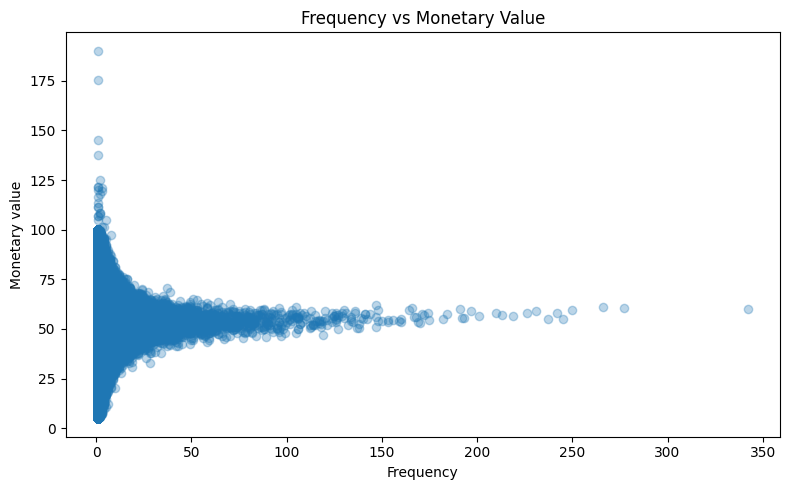

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm_summary['frequency'],
    rfm_summary['monetary_value'],
    alpha=0.3
)

plt.xlabel('Frequency')
plt.ylabel('Monetary value')
plt.title('Frequency vs Monetary Value')
plt.tight_layout()
plt.show()

### Visualization: Log Frequency vs Monetary Value

Because purchase frequency is usually skewed, this plot uses `log(1 + frequency)` to make the relationship easier to observe.

This chart is used as an additional visual check for the Gamma-Gamma assumption.

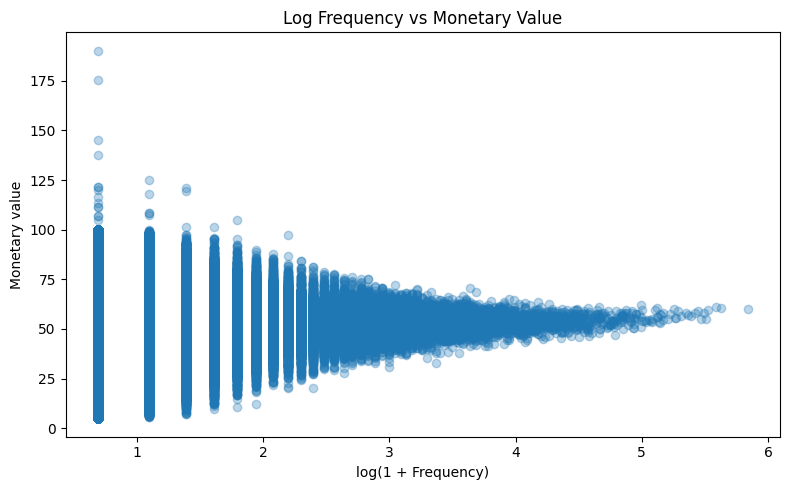

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    np.log1p(rfm_summary['frequency']),
    rfm_summary['monetary_value'],
    alpha=0.3
)

plt.xlabel('log(1 + Frequency)')
plt.ylabel('Monetary value')
plt.title('Log Frequency vs Monetary Value')
plt.tight_layout()
plt.show()

### Additional Diagnostic: Monetary Value Prediction Limitation

This step evaluates how well the Gamma-Gamma model predicts each customer's average transaction value in the holdout period.

The purpose of this diagnostic is not to prove that the monetary model is highly accurate at the individual customer level. Instead, it is used to understand the limitation of using expected average transaction value for customer-level forecasting.

In this project, the Gamma-Gamma model is mainly used as one component of a revenue-based CLV ranking and segmentation framework. Therefore, high MAE or RMSE in this diagnostic should be interpreted as a limitation of individual-level monetary prediction, not as a failure of the entire segmentation framework.

The final interpretation should rely more on:
- BG/NBD holdout validation for purchase-frequency prediction;
- p_alive validation for customer activity ranking;
- segment-level holdout validation for business usefulness.

In [37]:
monetary_validation_df = rfm_summary[
    rfm_summary['actual_transactions_6m'] > 0
].copy()

# Check expected monetary column
if 'expected_avg_sales' not in monetary_validation_df.columns:
    raise ValueError(
        "Column 'expected_avg_sales' not found. Please check the Gamma-Gamma prediction column name."
    )

# Actual average transaction value in holdout
y_true = monetary_validation_df['actual_avg_transaction_value_6m']
y_pred = monetary_validation_df['expected_avg_sales']

monetary_validation_df['absolute_percentage_error'] = (
    np.abs(y_pred - y_true) / y_true
) * 100

monetary_validation_df['percentage_error'] = (
    (y_pred - y_true) / y_true
) * 100

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = monetary_validation_df['absolute_percentage_error'].mean()
median_ape = monetary_validation_df['absolute_percentage_error'].median()
wape = (np.abs(y_pred - y_true).sum() / y_true.sum()) * 100
mean_percentage_bias = monetary_validation_df['percentage_error'].mean()
corr = y_true.corr(y_pred)

monetary_percentage_error_metrics = pd.DataFrame({
    'Metric': [
        'MAE',
        'RMSE',
        'MAPE (%)',
        'Median APE (%)',
        'WAPE (%)',
        'Mean percentage bias (%)',
        'Correlation'
    ],
    'Value': [
        mae,
        rmse,
        mape,
        median_ape,
        wape,
        mean_percentage_bias,
        corr
    ]
})

monetary_percentage_error_metrics


,Metric,Value
0,MAE,24.336911
1,RMSE,30.587061
2,MAPE (%),87.855761
3,Median APE (%),36.757825
4,WAPE (%),46.542729
5,Mean percentage bias (%),59.390539
6,Correlation,-0.009633


#### Interpretation of Monetary Value Diagnostic

The monetary-value diagnostic shows that the Gamma-Gamma model has limited individual-level accuracy in predicting average transaction value.

This means the estimated `expected_avg_sales` should not be interpreted as an exact forecast of how much each individual customer will spend in the future. Instead, it should be interpreted as a smoothed expected monetary value used together with BG/NBD purchase-frequency predictions to rank and segment customers.

Therefore, the CLV output in this project is more appropriate as a revenue-based customer ranking and segmentation indicator than as an exact customer-level revenue forecast.

## 8. Revenue-Based Customer Lifetime Value Estimation

Customer lifetime value is estimated by combining expected purchase frequency from the BG/NBD model with expected average transaction value from the Gamma-Gamma model.

In this project, the estimated CLV is revenue-based or transaction-value-based because the dataset does not contain gross margin, campaign cost, service cost, or cost-to-serve.

Therefore, the six-month CLV should be interpreted as an expected future transaction value indicator. It is useful for customer ranking and segmentation, but it should not be interpreted as exact profit-based CLV.

In [38]:
rfm_summary['CLV_6m'] = ggf.customer_lifetime_value(
    bgf,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T'],
    rfm_summary['monetary_value'],
    time=6,
    discount_rate=0.01,
    freq='D'
)

print("Top 20 customers have the highest predicted CLV in the next 6 months:")
display(rfm_summary.sort_values(by='CLV_6m', ascending=False).head(20))


Top 20 customers have the highest predicted CLV in the next 6 months:


,frequency,recency,T,monetary_value,pred_1m,pred_6m,pred_12m,p_alive,actual_6m,actual_transactions_6m,actual_value_6m,actual_avg_transaction_value_6m,actual_active_6m,p_alive_rank,p_alive_decile,naive_pred_6m,expected_avg_sales,CLV_6m
Customer_Name,,,,,,,,,,,,,,,,,,
Michael Smith,342.0,1416.0,1417.0,59.982222,5.684503,34.602368,68.852299,0.999817,50.0,56.0,3161.30,56.451786,1,139004.0,10,44.167960,60.003603,1972.742038
James Smith,277.0,1404.0,1408.0,60.520072,4.631589,28.192753,56.097555,0.999653,24.0,26.0,1644.09,63.234231,1,138993.0,10,36.002131,60.546576,1621.863867
Michael Johnson,266.0,1411.0,1414.0,61.003346,4.434212,26.991474,53.707611,0.999697,36.0,41.0,1690.49,41.231463,1,139000.0,10,34.425743,61.031045,1565.181267
Christopher Smith,250.0,1410.0,1416.0,59.554400,4.163830,25.345659,50.432830,0.999523,35.0,37.0,2105.05,56.893243,1,138971.0,10,32.309322,59.583559,1434.885512
David Smith,242.0,1413.0,1416.0,57.992975,4.032103,24.543805,48.837266,0.999680,43.0,47.0,2482.13,52.811277,1,138997.0,10,31.275424,58.022749,1353.092305
Michael Jones,231.0,1411.0,1416.0,59.071255,3.849671,23.433307,46.627551,0.999574,26.0,28.0,1426.06,50.930714,1,138982.0,10,29.853814,59.102700,1315.915920
Michael Williams,245.0,1407.0,1413.0,55.201755,4.087862,24.883140,49.512311,0.999521,28.0,32.0,1793.45,56.045313,1,138970.0,10,31.730361,55.230549,1305.785423
John Smith,237.0,1378.0,1390.0,55.048312,4.003756,24.370526,48.490930,0.998909,25.0,29.0,1219.78,42.061379,1,138727.0,10,31.202158,55.078043,1275.354792
Jennifer Smith,226.0,1405.0,1417.0,57.957345,3.762559,22.903059,45.572497,0.998961,25.0,27.0,1284.98,47.591852,1,138753.0,10,29.187015,57.989219,1261.908863


## 9. Customer Segmentation

K-Means clustering is applied using two model-based features: probability alive and predicted CLV. The resulting clusters are mapped into four business-oriented customer segments: Lost, At Risk, Potential, and VIP.


In [39]:
cluster_features = rfm_summary[['p_alive', 'CLV_6m']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_summary['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

cluster_profile = rfm_summary.groupby('KMeans_Cluster')[['p_alive', 'CLV_6m']].mean()
cluster_profile['Composite_Score'] = (
    cluster_profile['p_alive'].rank(method='first') +
    cluster_profile['CLV_6m'].rank(method='first')
)

ordered_clusters = cluster_profile.sort_values(['p_alive', 'CLV_6m']).index.tolist()
segment_labels = ['Lost', 'At Risk', 'Potential', 'VIP']
cluster_name_map = {cluster_id: segment_labels[idx] for idx, cluster_id in enumerate(ordered_clusters)}

rfm_summary['KMeans_Segment'] = rfm_summary['KMeans_Cluster'].map(cluster_name_map)
cluster_profile['KMeans_Segment'] = cluster_profile.index.map(cluster_name_map)
cluster_profile['Sample size'] = rfm_summary['KMeans_Cluster'].value_counts().reindex(cluster_profile.index).values
cluster_profile['Percentage of Customers'] = (
    rfm_summary['KMeans_Cluster']
    .value_counts(normalize=True)
    .reindex(cluster_profile.index)
    .values * 100
).round(2).astype(str)

cluster_profile = cluster_profile[
    ['p_alive', 'CLV_6m', 'KMeans_Segment', 'Composite_Score', 'Sample size', 'Percentage of Customers']
]

cluster_profile


,p_alive,CLV_6m,KMeans_Segment,Composite_Score,Sample size,Percentage of Customers
KMeans_Cluster,,,,,,
0,0.954440,41.663807,Potential,6.0,70073,50.41
1,0.724999,16.652732,At Risk,4.0,44568,32.06
2,0.352479,7.278814,Lost,2.0,22460,16.16
3,0.996070,285.585159,VIP,8.0,1903,1.37


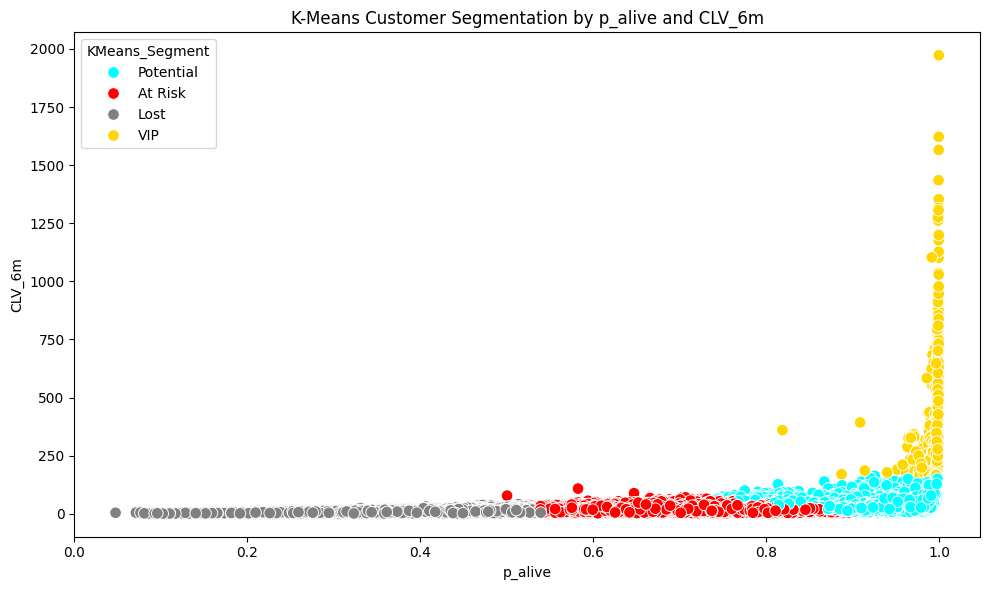

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm_summary,
    x='p_alive',
    y='CLV_6m',
    hue='KMeans_Segment',
    palette={'VIP': 'gold', 'At Risk': 'red', 'Potential': 'cyan', 'Lost': 'grey'},
    s=70
)

plt.title('K-Means Customer Segmentation by p_alive and CLV_6m')
plt.legend(title='KMeans_Segment')
plt.tight_layout()
plt.show()


### Additional Validation 4: Segment Holdout Validation

After creating the K-means customer segments, this step checks whether the segments are meaningful when compared with actual customer behavior in the 6-month holdout period.

The goal is to evaluate whether groups such as VIP, Potential, At-risk, and Lost show different actual active rates, transaction counts, and transaction values in the holdout data.

This validation helps assess whether the CLV-based segmentation is economically useful, not just technically generated by K-means.

In [41]:
# Reuse holdout actuals created earlier.
# actual_6m = unique customer-day purchase periods
# actual_transactions_6m = raw transaction count
# actual_value_6m = total holdout transaction value

rfm_summary = add_holdout_actuals(rfm_summary, holdout_data)

rfm_summary[
    ['actual_6m', 'actual_transactions_6m', 'actual_active_6m', 'actual_value_6m']
].head()


,actual_6m,actual_transactions_6m,actual_active_6m,actual_value_6m
Customer_Name,,,,
Aaron Acevedo,0.0,0.0,0,0.00
Aaron Acosta,0.0,0.0,0,0.00
Aaron Adams,1.0,1.0,1,80.04
Aaron Adkins,0.0,0.0,0,0.00
Aaron Aguilar,1.0,1.0,1,56.16


In [42]:
segment_col = 'KMeans_Segment'

segment_holdout_validation = (
    rfm_summary
    .groupby(segment_col)
    .agg(
        customers=(segment_col, 'size'),
        avg_predicted_CLV=('CLV_6m', 'mean'),
        avg_p_alive=('p_alive', 'mean'),
        actual_active_rate=('actual_active_6m', 'mean'),
        avg_actual_purchase_periods_6m=('actual_6m', 'mean'),
        avg_actual_value_6m=('actual_value_6m', 'mean'),
        total_actual_value_6m=('actual_value_6m', 'sum')
    )
    .sort_values('avg_predicted_CLV', ascending=False)
)

segment_holdout_validation

,customers,avg_predicted_CLV,avg_p_alive,actual_active_rate,avg_actual_purchase_periods_6m,avg_actual_value_6m,total_actual_value_6m
KMeans_Segment,,,,,,,
VIP,1903,285.585159,0.996070,0.993694,6.646873,356.659044,678722.16
Potential,70073,41.663807,0.954440,0.435646,0.708704,37.273176,2611843.24
At Risk,44568,16.652732,0.724999,0.193749,0.230681,12.023949,535883.37
Lost,22460,7.278814,0.352479,0.173642,0.202850,10.678564,239840.54


### Visualization: Average actual holdout value by segment

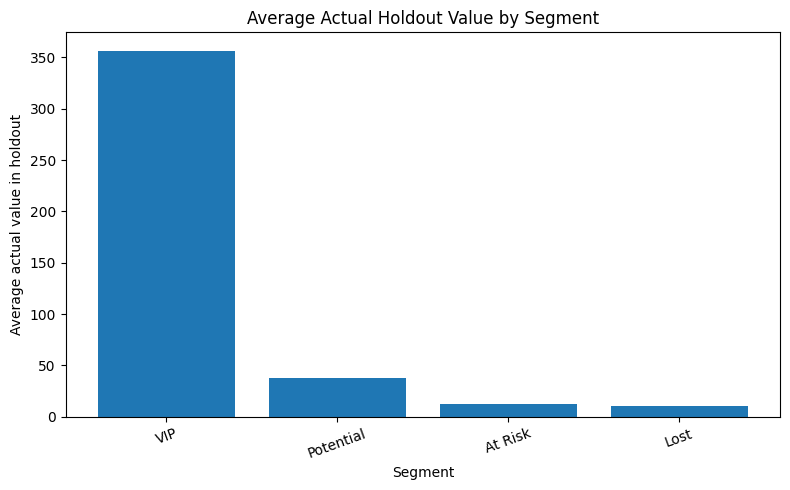

In [43]:
plot_df = segment_holdout_validation.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df.index.astype(str),
    plot_df['avg_actual_value_6m']
)

plt.xlabel('Segment')
plt.ylabel('Average actual value in holdout')
plt.title('Average Actual Holdout Value by Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Visualization: Actual active rate by segment

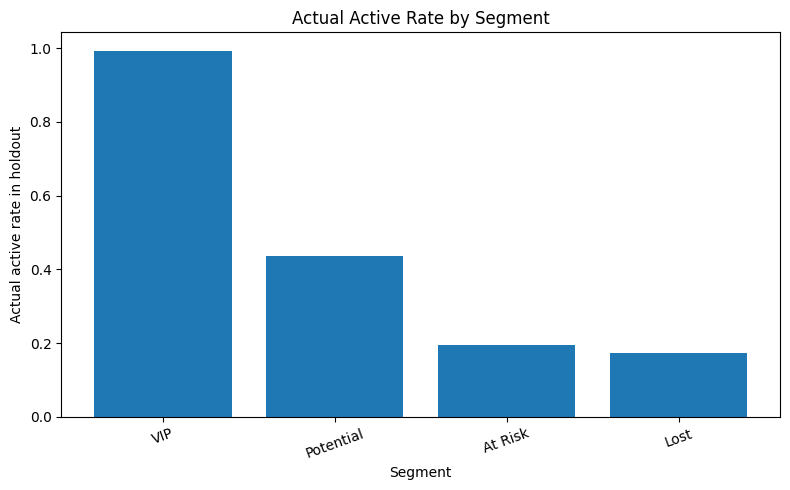

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    plot_df.index.astype(str),
    plot_df['actual_active_rate']
)

plt.xlabel('Segment')
plt.ylabel('Actual active rate in holdout')
plt.title('Actual Active Rate by Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Visualization: Average actual purchase periods by segment


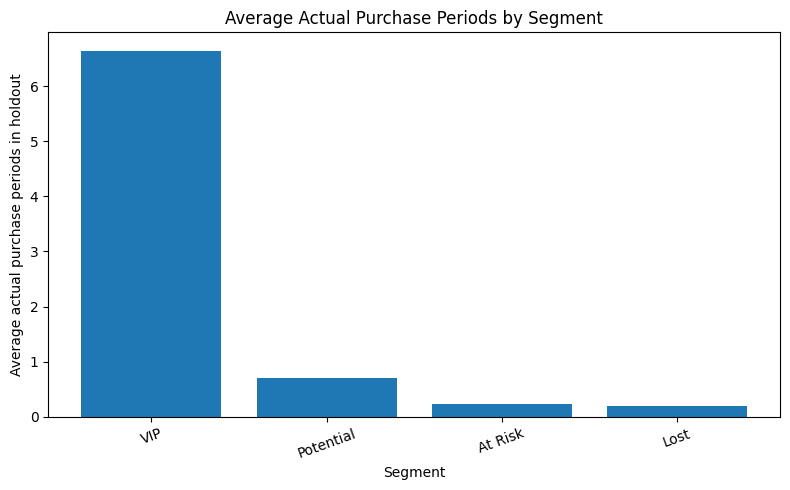

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    plot_df.index.astype(str),
    plot_df['avg_actual_purchase_periods_6m']
)

plt.xlabel('Segment')
plt.ylabel('Average actual purchase periods in holdout')
plt.title('Average Actual Purchase Periods by Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Compare predicted CLV rank with actual holdout value rank

In [46]:
segment_ranking_check = segment_holdout_validation.copy()

segment_ranking_check['predicted_CLV_rank'] = (
    segment_ranking_check['avg_predicted_CLV']
    .rank(ascending=False, method='dense')
)

segment_ranking_check['actual_value_rank'] = (
    segment_ranking_check['avg_actual_value_6m']
    .rank(ascending=False, method='dense')
)

segment_ranking_check[
    [
        'customers',
        'avg_predicted_CLV',
        'avg_actual_value_6m',
        'predicted_CLV_rank',
        'actual_value_rank',
        'avg_p_alive',
        'actual_active_rate',
        'avg_actual_purchase_periods_6m'
    ]
]

,customers,avg_predicted_CLV,avg_actual_value_6m,predicted_CLV_rank,actual_value_rank,avg_p_alive,actual_active_rate,avg_actual_purchase_periods_6m
KMeans_Segment,,,,,,,,
VIP,1903,285.585159,356.659044,1.0,1.0,0.996070,0.993694,6.646873
Potential,70073,41.663807,37.273176,2.0,2.0,0.954440,0.435646,0.708704
At Risk,44568,16.652732,12.023949,3.0,3.0,0.724999,0.193749,0.230681
Lost,22460,7.278814,10.678564,4.0,4.0,0.352479,0.173642,0.202850


#### Interpretation of Segment-Level Holdout Validation

The segment-level holdout validation is one of the most important checks in this notebook.

Although the Gamma-Gamma model has limited individual-level monetary prediction accuracy, the customer segments should still be evaluated at the group level. If the segmentation is useful, segments with higher predicted CLV and higher `p_alive` should also show stronger actual behavior in the holdout period.

The validation compares segments using:
- actual active rate in the holdout period;
- average actual purchase periods;
- average actual transaction value;
- total actual transaction value.

If VIP and Potential customers show higher actual holdout value and stronger activity than At Risk and Lost customers, this supports the business usefulness of the segmentation.

Therefore, the main conclusion is not that the model perfectly predicts each customer's future spending. The stronger conclusion is that the model creates meaningful customer groups for CRM prioritization.

### Additional Sensitivity Check: Revenue-Based CLV vs Assumed Profit-Based CLV

The CLV calculated in this project is revenue-based or transaction-value-based because the dataset does not include gross margin, campaign cost, service cost, or cost-to-serve.

This sensitivity check applies assumed margin rates to convert revenue-based CLV into approximate profit-based CLV.

The purpose is not to create a final profit model, but to show how the framework could be extended if margin data were available.

In [47]:
margin_rates = [0.10, 0.20, 0.30, 0.40]

profit_sensitivity_results = []

for margin in margin_rates:
    temp = rfm_summary.copy()
    temp['assumed_profit_CLV_6m'] = temp['CLV_6m'] * margin
    
    segment_profit = (
        temp
        .groupby(segment_col)
        .agg(
            customers=(segment_col, 'size'),
            avg_revenue_based_CLV=('CLV_6m', 'mean'),
            avg_assumed_profit_CLV=('assumed_profit_CLV_6m', 'mean'),
            total_assumed_profit_CLV=('assumed_profit_CLV_6m', 'sum')
        )
        .reset_index()
    )
    
    segment_profit['assumed_margin_rate'] = margin
    
    profit_sensitivity_results.append(segment_profit)

profit_sensitivity = pd.concat(profit_sensitivity_results, ignore_index=True)

profit_sensitivity.sort_values(
    ['assumed_margin_rate', 'avg_assumed_profit_CLV'],
    ascending=[True, False]
)

,KMeans_Segment,customers,avg_revenue_based_CLV,avg_assumed_profit_CLV,total_assumed_profit_CLV,assumed_margin_rate
3,VIP,1903,285.585159,28.558516,5.434686e+04,0.1
2,Potential,70073,41.663807,4.166381,2.919508e+05,0.1
0,At Risk,44568,16.652732,1.665273,7.421789e+04,0.1
1,Lost,22460,7.278814,0.727881,1.634822e+04,0.1
7,VIP,1903,285.585159,57.117032,1.086937e+05,0.2
6,Potential,70073,41.663807,8.332761,5.839016e+05,0.2
4,At Risk,44568,16.652732,3.330546,1.484358e+05,0.2
5,Lost,22460,7.278814,1.455763,3.269643e+04,0.2
11,VIP,1903,285.585159,85.675548,1.630406e+05,0.3
10,Potential,70073,41.663807,12.499142,8.758524e+05,0.3


### Additional Diagnostic: K-Selection and Business Interpretability

The main analysis uses K = 4 in K-means clustering to create four CRM-actionable customer segments: Lost, At Risk, Potential, and VIP.

This step checks whether the selected number of clusters is reasonable from both a technical and business perspective.

Two technical indicators are used:

- **Elbow method**: checks how inertia decreases as K increases.
- **Silhouette score**: checks how clearly separated the clusters are.

However, the final choice of K should not rely only on the highest silhouette score. In customer segmentation, the clusters must also be interpretable and useful for marketing decisions.

Therefore, K = 4 is evaluated as a business-driven segmentation choice, not only as a purely technical optimum.

In [48]:
# Use the same clustering features as the main K-means model
cluster_features_check = rfm_summary[['p_alive', 'CLV_6m']].copy()

# Standardize features because K-means is distance-based
scaler_check = StandardScaler()
scaled_features_check = scaler_check.fit_transform(cluster_features_check)

print("Clustering features prepared successfully.")
print("Shape of scaled features:", scaled_features_check.shape)

Clustering features prepared successfully.
Shape of scaled features: (139004, 2)


In [49]:
k_range = range(2, 9)

inertias = []
silhouette_scores = []

# Use a sample for silhouette score to reduce computation time
sample_size = min(5000, scaled_features_check.shape[0])

rng = np.random.default_rng(42)
sample_idx = rng.choice(
    scaled_features_check.shape[0],
    size=sample_size,
    replace=False
)

scaled_sample = scaled_features_check[sample_idx]

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_full = km.fit_predict(scaled_features_check)
    
    # Inertia on full data
    inertias.append(km.inertia_)
    
    # Silhouette score on sampled data
    labels_sample = labels_full[sample_idx]
    sil_score = silhouette_score(scaled_sample, labels_sample)
    silhouette_scores.append(sil_score)

k_selection_result = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Silhouette_sample': silhouette_scores
})

k_selection_result

,K,Inertia,Silhouette_sample
0,2,161643.560534,0.545035
1,3,97523.046196,0.577315
2,4,70999.647518,0.491318
3,5,47701.033015,0.516567
4,6,36743.739427,0.513005
5,7,29742.351463,0.490129
6,8,23408.226799,0.485578


### Visualization: Elbow Method

The elbow method shows how inertia decreases as the number of clusters increases.

Inertia usually decreases when K increases, but after a certain point, the improvement becomes smaller. A reasonable K is often located around the point where the curve starts to flatten.

This chart is used as a technical reference for evaluating whether K = 4 is reasonable.

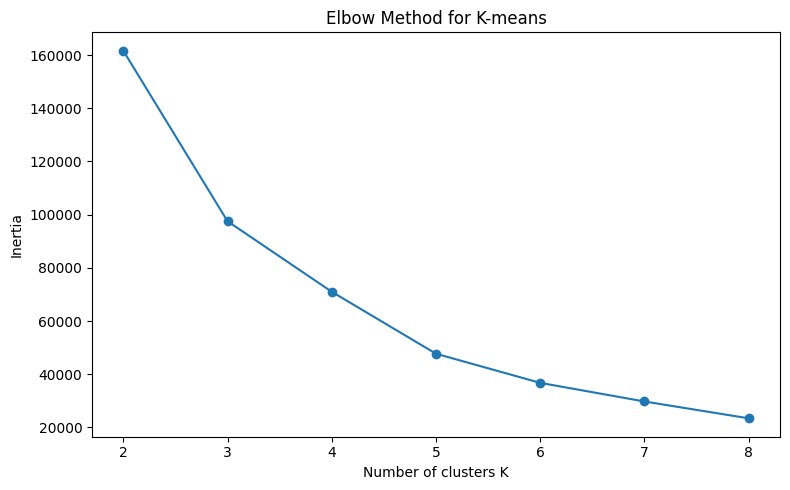

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_selection_result['K'],
    k_selection_result['Inertia'],
    marker='o'
)

plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-means')
plt.tight_layout()
plt.show()

### Visualization: Silhouette Score by K

The silhouette score measures how well-separated the clusters are. A higher score suggests clearer geometric separation between clusters.

However, the highest silhouette score does not automatically determine the best segmentation for this project. A smaller number of clusters may look better technically but may combine customers with different CRM meanings into the same group.

Therefore, this chart should be interpreted together with business actionability. The selected K should create customer groups that are both reasonably separated and meaningful for CRM strategy.

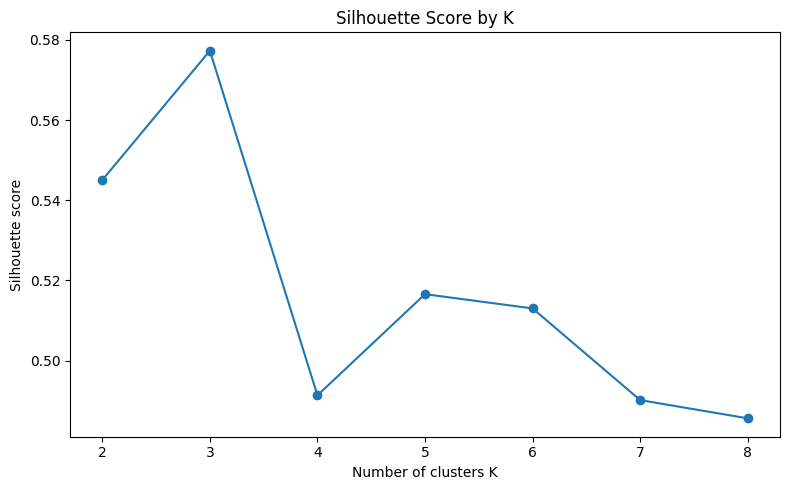

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_selection_result['K'],
    k_selection_result['Silhouette_sample'],
    marker='o'
)

plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by K')
plt.tight_layout()
plt.show()

### Additional Check: Comparing K = 3, K = 4, and K = 5

Since the silhouette score may favor a smaller number of clusters, this step compares K = 3, K = 4, and K = 5 in terms of business interpretability.

The purpose is not to automatically replace the main K = 4 segmentation. Instead, this check evaluates whether K = 4 produces a useful customer structure compared with nearby alternatives.

For each K, we examine:
- cluster size;
- average `p_alive`;
- average six-month CLV.

K = 4 is retained if it provides a clearer CRM action framework, especially the separation of Lost, At Risk, Potential, and VIP customers.

In [52]:
profile_results = []

for k in [3, 4, 5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(scaled_features_check)
    
    temp = rfm_summary[['p_alive', 'CLV_6m']].copy()
    temp['cluster'] = labels
    
    profile = (
        temp
        .groupby('cluster')
        .agg(
            customers=('cluster', 'size'),
            avg_p_alive=('p_alive', 'mean'),
            avg_CLV_6m=('CLV_6m', 'mean')
        )
        .reset_index()
    )
    
    profile['K'] = k
    profile['share'] = profile['customers'] / len(temp)
    
    profile_results.append(profile)

cluster_profile_comparison = pd.concat(profile_results, ignore_index=True)

cluster_profile_comparison = cluster_profile_comparison[
    ['K', 'cluster', 'customers', 'share', 'avg_p_alive', 'avg_CLV_6m']
].sort_values(['K', 'avg_CLV_6m'], ascending=[True, False])

cluster_profile_comparison

,K,cluster,customers,share,avg_p_alive,avg_CLV_6m
1,3,1,2389,0.017187,0.995704,258.810615
2,3,2,99236,0.713908,0.901216,34.120803
0,3,0,37379,0.268906,0.459955,9.746838
6,4,3,1903,0.013690,0.996070,285.585159
3,4,0,70073,0.504108,0.954440,41.663807
4,4,1,44568,0.320624,0.724999,16.652732
5,4,2,22460,0.161578,0.352479,7.278814
8,5,1,417,0.003000,0.997552,521.575135
10,5,3,5499,0.039560,0.992374,144.663657
7,5,0,67924,0.488648,0.949639,36.623287


#### Interpretation of K-Selection Diagnostic

The K-selection diagnostic should be interpreted together with the business objective of the project.

If K = 3 has a higher silhouette score, it suggests that three clusters may be more compact or better separated geometrically. However, K = 3 may be too coarse for CRM strategy because it can merge customers with different business meanings.

K = 4 is selected because it supports a clearer action-oriented segmentation framework:

- **Lost**: low activity probability and low expected value;
- **At Risk**: moderate activity probability but limited expected value;
- **Potential**: high activity probability with growth opportunity;
- **VIP**: very high activity probability and high expected value.

Therefore, the selection of K = 4 is justified primarily by CRM interpretability and actionability, while the silhouette score is used as a diagnostic reference rather than the sole decision rule.